# Logistic Regression for Classification

## Overview

Logistic regression is the canonical linear classifier. It models the log-odds of a binary outcome as a linear combination of predictors, producing calibrated probability estimates. It should be the **default starting point** for any binary classification task — before reaching for random forests or gradient boosting.

**Why start here:**
- Coefficients are directly interpretable as odds ratios
- Probability outputs are naturally calibrated
- Computationally trivial even on large datasets
- Sets a performance baseline: if XGBoost barely beats logistic regression, the gain may not justify the complexity
- Assumption violations are diagnosable and often fixable

**Extensions covered:**
- Regularised logistic regression (ridge / LASSO / elastic net) via `glmnet` — handles many predictors and multicollinearity
- Threshold selection — default 0.5 is rarely optimal; optimise for the task metric

## Applications by Sector

| Sector | Binary outcome |
|---|---|
| **Ecology** | Presence / absence of a species at a site |
| **Healthcare** | Disease positive / negative; readmission yes / no |
| **Insurance** | Claim yes / no; fraud yes / no |
| **Finance** | Default yes / no; churn yes / no |

---

## Setup

In [2]:
library(tidyverse)
library(ggplot2)
library(glmnet)      # regularised logistic regression
library(yardstick)   # tidymodels metrics: roc_auc, f_meas, etc.
library(probably)    # threshold optimisation
library(patchwork)
library(broom)

set.seed(42)

# ── Simulate: species presence/absence at 400 sites ───────────────────────────
n <- 400
clf_data <- tibble(
  nitrate     = rnorm(n, 3, 1.2),
  water_qual  = rnorm(n, 6, 1.5),
  distance_km = rexp(n, 0.4),
  elevation   = rnorm(n, 200, 80),
  habitat     = factor(sample(c("reference","restored","degraded"), n,
                              replace=TRUE, prob=c(.35,.35,.30)),
                       levels=c("reference","restored","degraded")),
  log_odds    = -1 + 0.5*water_qual - 0.6*nitrate - 0.3*distance_km +
                case_when(habitat=="reference"~0.8, habitat=="restored"~0.2,
                          habitat=="degraded"~ -0.9),
  present     = factor(rbinom(n, 1, plogis(log_odds)),
                       levels=c(0,1), labels=c("absent","present"))
)

cat(sprintf("Prevalence: %.1f%% present\n", mean(clf_data$present=="present")*100))

# Train/test split (75/25)
train_idx  <- sample(n, floor(0.75*n))
train_data <- clf_data[train_idx,]
test_data  <- clf_data[-train_idx,]

Warning message:
"package 'probably' was built under R version 4.4.3"

Attaching package: 'probably'


The following objects are masked from 'package:base':

    as.factor, as.ordered


Warning message:
"package 'patchwork' was built under R version 4.4.3"
Warning message:
"package 'broom' was built under R version 4.4.3"


Prevalence: 40.8% present


---

## Standard Logistic Regression

In [3]:
# Fit
m_logit <- glm(
  present ~ nitrate + water_qual + distance_km + elevation + habitat,
  data   = train_data,
  family = binomial(link="logit")
)
summary(m_logit)

# ── Odds ratios ───────────────────────────────────────────────────────────────
or_table <- broom::tidy(m_logit, exponentiate=TRUE, conf.int=TRUE) %>%
  filter(term != "(Intercept)") %>%
  mutate(across(c(estimate, conf.low, conf.high), ~round(.x,3)))
print(or_table)
# OR > 1: predictor associated with higher probability of presence
# OR < 1: predictor associated with lower probability of presence

# ── Predictions on test set ───────────────────────────────────────────────────
test_preds <- test_data %>%
  mutate(
    prob_present = predict(m_logit, newdata=test_data, type="response"),
    pred_class   = factor(ifelse(prob_present >= 0.5, "present", "absent"),
                          levels=c("absent","present"))
  )

# Quick accuracy metrics
yardstick::metrics(test_preds, truth=present, estimate=pred_class) %>% print()
yardstick::roc_auc(test_preds, truth=present, prob_present,
                   event_level="second") %>% print()


Call:
glm(formula = present ~ nitrate + water_qual + distance_km + 
    elevation + habitat, family = binomial(link = "logit"), data = train_data)

Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)     -0.6825216  0.8244832  -0.828 0.407774    
nitrate         -0.4444574  0.1303315  -3.410 0.000649 ***
water_qual       0.5658030  0.1052798   5.374 7.69e-08 ***
distance_km     -0.3111931  0.0714182  -4.357 1.32e-05 ***
elevation       -0.0008771  0.0016544  -0.530 0.595992    
habitatrestored -0.9345371  0.3388007  -2.758 0.005809 ** 
habitatdegraded -1.6466347  0.3420259  -4.814 1.48e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 405.37  on 299  degrees of freedom
Residual deviance: 317.60  on 293  degrees of freedom
AIC: 331.6

Number of Fisher Scoring iterations: 4


# A tibble: 6 × 7
  term            estimate std.error statistic      p.value conf.low conf.high
  <chr>              <dbl>     <dbl>     <dbl>        <dbl>    <dbl>     <dbl>
1 nitrate            0.641   0.130      -3.41  0.000649        0.493     0.823
2 water_qual         1.76    0.105       5.37  0.0000000769    1.44      2.18 
3 distance_km        0.733   0.0714     -4.36  0.0000132       0.632     0.837
4 elevation          0.999   0.00165    -0.530 0.596           0.996     1.00 
5 habitatrestored    0.393   0.339      -2.76  0.00581         0.2       0.757
6 habitatdegraded    0.193   0.342      -4.81  0.00000148      0.097     0.372
# A tibble: 2 × 3
  .metric  .estimator .estimate
  <chr>    <chr>          <dbl>
1 accuracy binary         0.72 
2 kap      binary         0.413
# A tibble: 1 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 roc_auc binary         0.804


---

## Regularised Logistic Regression with `glmnet`

Ridge CV-AUC (lambda.min): 0.7864
LASSO CV-AUC (lambda.min): 0.7920
Elastic net CV-AUC:        0.7924
5 x 1 sparse Matrix of class "dgCMatrix"
                        s1
(Intercept)     -1.1016139
nitrate         -0.1273125
water_qual       0.2615583
distance_km     -0.1099977
habitatdegraded -0.5020210


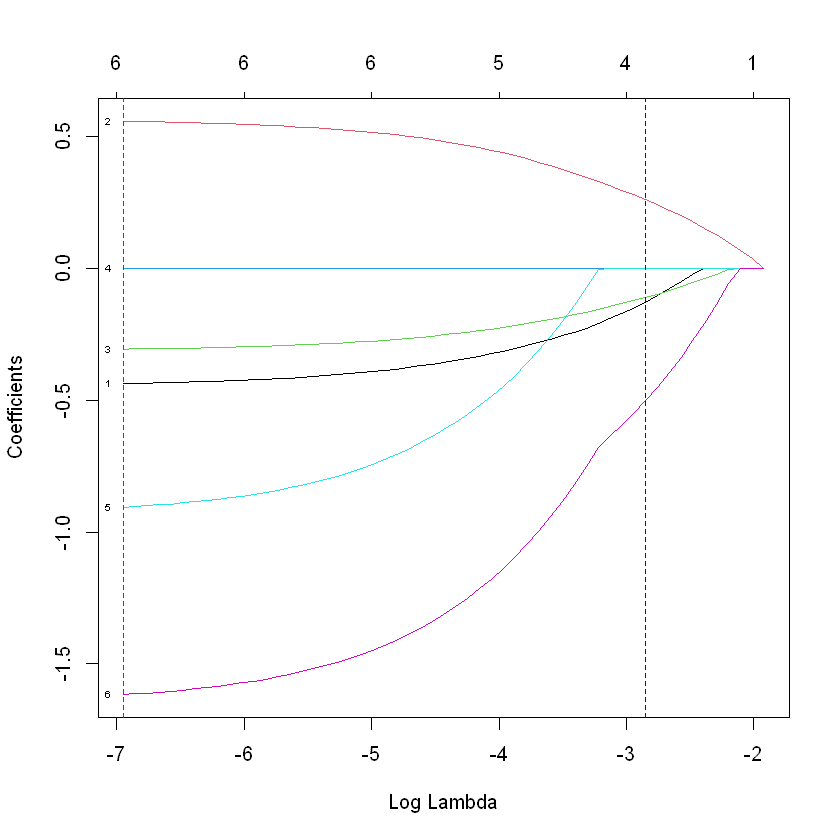

In [4]:
# glmnet requires a model matrix (no formula interface)
X_train <- model.matrix(present ~ nitrate + water_qual + distance_km +
                          elevation + habitat, data=train_data)[,-1]
y_train <- train_data$present
X_test  <- model.matrix(present ~ nitrate + water_qual + distance_km +
                          elevation + habitat, data=test_data)[,-1]

# ── Ridge (alpha=0), LASSO (alpha=1), Elastic net (alpha=0.5) ─────────────────
# Cross-validate to select lambda for each
cv_ridge <- cv.glmnet(X_train, y_train, family="binomial", alpha=0,
                       type.measure="auc", nfolds=10)
cv_lasso <- cv.glmnet(X_train, y_train, family="binomial", alpha=1,
                       type.measure="auc", nfolds=10)
cv_enet  <- cv.glmnet(X_train, y_train, family="binomial", alpha=0.5,
                       type.measure="auc", nfolds=10)

cat(sprintf("Ridge CV-AUC (lambda.min): %.4f\n", max(cv_ridge$cvm)))
cat(sprintf("LASSO CV-AUC (lambda.min): %.4f\n", max(cv_lasso$cvm)))
cat(sprintf("Elastic net CV-AUC:        %.4f\n", max(cv_enet$cvm)))

# ── LASSO coefficient path ────────────────────────────────────────────────────
plot(cv_lasso$glmnet.fit, xvar="lambda", label=TRUE)
abline(v=log(cv_lasso$lambda.min), lty=2, col="red")
abline(v=log(cv_lasso$lambda.1se), lty=2, col="blue")
# lambda.min: minimises CV error
# lambda.1se: sparsest model within 1 SE of minimum — preferred for parsimony

# ── Non-zero LASSO coefficients at lambda.1se ────────────────────────────────
lasso_coef <- coef(cv_lasso, s="lambda.1se")
print(lasso_coef[lasso_coef[,1] != 0, , drop=FALSE])

---

## Threshold Optimisation

In [5]:
# The default threshold of 0.5 maximises accuracy under equal class prevalence
# When classes are imbalanced OR costs of FP/FN differ, optimise the threshold

# ── Youden's J: maximises sensitivity + specificity - 1 (balanced threshold) ──
roc_data <- yardstick::roc_curve(
  test_preds, truth=present, prob_present, event_level="second"
)

youden_thresh <- roc_data %>%
  mutate(j = sensitivity + specificity - 1) %>%
  slice_max(j, n=1) %>%
  pull(.threshold)

cat(sprintf("Optimal threshold (Youden's J): %.3f\n", youden_thresh))

# ── Precision-Recall optimal threshold ────────────────────────────────────────
pr_data <- yardstick::pr_curve(
  test_preds, truth=present, prob_present, event_level="second"
)

f1_thresh <- pr_data %>%
  mutate(f1 = 2*(precision*recall)/(precision+recall)) %>%
  slice_max(f1, n=1) %>%
  pull(.threshold)

cat(sprintf("Optimal threshold (F1):         %.3f\n", f1_thresh))

# ── Compare performance at each threshold ─────────────────────────────────────
eval_at_thresh <- function(preds, prob_col, thresh, label) {
  preds %>%
    mutate(pred = factor(ifelse({{prob_col}} >= thresh, "present","absent"),
                         levels=c("absent","present"))) %>%
    yardstick::metrics(truth=present, estimate=pred) %>%
    mutate(threshold=label)
}

bind_rows(
  eval_at_thresh(test_preds, prob_present, 0.5,           "0.5 (default)"),
  eval_at_thresh(test_preds, prob_present, youden_thresh, "Youden"),
  eval_at_thresh(test_preds, prob_present, f1_thresh,     "Max F1")
) %>% pivot_wider(names_from=.metric, values_from=.estimate) %>% print()

Optimal threshold (Youden's J): 0.367
Optimal threshold (F1):         0.367
# A tibble: 3 × 4
  .estimator threshold     accuracy   kap
  <chr>      <chr>            <dbl> <dbl>
1 binary     0.5 (default)     0.72 0.413
2 binary     Youden            0.74 0.486
3 binary     Max F1            0.74 0.486


---

## Visualisation

Warning message:
"The `fatten` argument of `geom_pointrange()` is deprecated as of ggplot2 4.0.0.
ℹ Please use the `size` aesthetic instead."


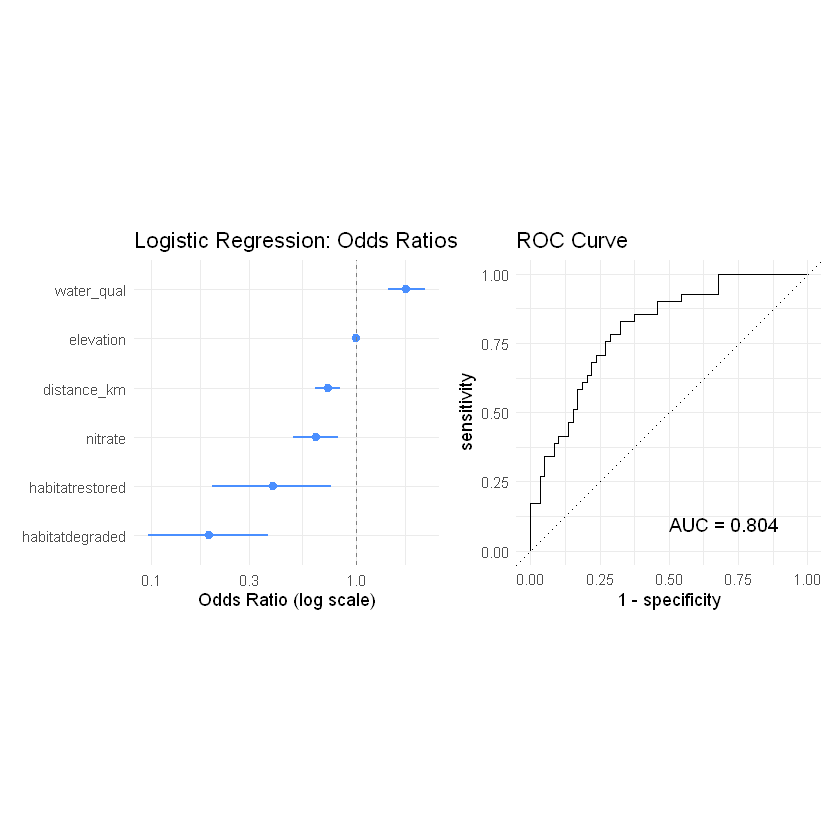

In [6]:
# ── Odds ratio forest plot ────────────────────────────────────────────────────
p_or <- or_table %>%
  ggplot(aes(x=estimate, xmin=conf.low, xmax=conf.high,
             y=fct_reorder(term, estimate))) +
  geom_pointrange(color="#4a8fff", linewidth=0.8, fatten=3) +
  geom_vline(xintercept=1, linetype="dashed", color="gray50") +
  scale_x_log10() +
  labs(title="Logistic Regression: Odds Ratios",
       x="Odds Ratio (log scale)", y=NULL) +
  theme_minimal()

# ── ROC curve ────────────────────────────────────────────────────────────────
auc_val <- yardstick::roc_auc(test_preds, present, prob_present,
                               event_level="second")$.estimate
p_roc <- autoplot(roc_data) +
  annotate("text", x=0.7, y=0.1,
           label=sprintf("AUC = %.3f", auc_val), size=4) +
  labs(title="ROC Curve") + theme_minimal()

(p_or | p_roc)

---

## Common Pitfalls

**1. Using accuracy as the primary metric with imbalanced classes**  
A model predicting "absent" for every site achieves 60% accuracy if prevalence is 40%. Always report AUC-ROC, sensitivity, specificity, and F1 alongside accuracy. See `model_evaluation.ipynb` and `imbalanced_data.ipynb`.

**2. Not checking the linearity-of-log-odds assumption for continuous predictors**  
Logistic regression assumes a linear relationship between each continuous predictor and the log-odds. Check this with partial residual plots (`car::crPlots()`) or by adding spline terms. A strongly non-linear relationship will hurt performance and bias coefficient estimates.

**3. Using 0.5 as the classification threshold without justification**  
0.5 is only optimal when classes are balanced and false positives and false negatives have equal cost. In ecology (rare species detection) or medicine (disease screening), the costs differ dramatically. Always optimise the threshold explicitly.

**4. Interpreting LASSO-excluded variables as unimportant**  
LASSO sets some coefficients to exactly zero as a selection mechanism. A zero coefficient means "not selected given the other variables at this regularisation level" — not "the variable has no effect." Correlated variables may be arbitrarily selected/excluded by LASSO.

**5. Forgetting to check for complete separation**  
If a predictor perfectly separates the two classes, `glm()` will return extreme coefficients and inflated standard errors without an error. Check with `car::Anova()` or use `logistf` (Firth's penalised likelihood) when separation is suspected.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*